In [6]:
# %% === Install Required Packages ===
!pip install --quiet pandas numpy matplotlib seaborn scikit-learn torch xgboost joblib tqdm pytorch-tabnet nltk textstat emoji

In [7]:
# %% === Imports ===
import pandas as pd, numpy as np, re, os, time, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, 
    ExtraTreesRegressor, HistGradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import BayesianRidge, Ridge
from sklearn.svm import LinearSVR
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import StackingRegressor
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import joblib
from pytorch_tabnet.tab_model import TabNetRegressor
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import textstat
import emoji

# Download VADER lexicon
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\mercy\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [8]:
# === Config ===
pd.options.mode.chained_assignment = None  # Suppress pandas SettingWithCopyWarning
torch.manual_seed(42)
np.random.seed(42)

DATASET_PATH = "../../../Dataset/Mohamed_Dataset/snapshots/youtube_dataset_snapshot_20251028_144628.csv"

In [9]:
# %% === Load Data ===
data = pd.read_csv(DATASET_PATH, low_memory=False)
data['title'] = data['title'].astype(str)
data = data[~data['title'].str.contains('#', regex=False, na=False)] # Remove rows with '#' in title

In [10]:
# %% === Feature Engineering ===
# --- Tabular Features ---
data['publishedAt'] = pd.to_datetime(data['publishedAt'], errors='coerce')
data['pub_year'] = data['publishedAt'].dt.year
data['pub_month'] = data['publishedAt'].dt.month
data['pub_day'] = data['publishedAt'].dt.day
data['pub_weekday'] = data['publishedAt'].dt.weekday
data['pub_hour'] = data['publishedAt'].dt.hour
data['days_since_first_video'] = (data['publishedAt'] - data['publishedAt'].min()).dt.days

def duration_to_seconds(d):
    if not isinstance(d, str): return 0
    h = int(re.search(r'(\d+)H', d).group(1)) if 'H' in d else 0
    m = int(re.search(r'(\d+)M', d).group(1)) if 'M' in d else 0
    s = int(re.search(r'(\d+)S', d).group(1)) if 'S' in d else 0
    return h * 3600 + m * 60 + s

data['duration_sec'] = data['duration'].apply(duration_to_seconds)

# --- Text Features ---
sid = SentimentIntensityAnalyzer()
data['sentiment'] = data['title'].apply(lambda x: sid.polarity_scores(x)['compound'])
data['readability'] = data['title'].apply(textstat.flesch_reading_ease)
data['title_length'] = data['title'].apply(len)
data['word_count'] = data['title'].apply(lambda x: len(x.split()))
data['uppercase_word_count'] = data['title'].apply(lambda x: len([w for w in x.split() if w.isupper()]))
data['emoji_count'] = data['title'].apply(emoji.emoji_count)
data['punctuation_count'] = data['title'].apply(lambda x: len([c for c in x if c in '.,?!:;']))
data['has_question_mark'] = data['title'].apply(lambda x: '?' in x).astype(int)
data['has_exclamation_mark'] = data['title'].apply(lambda x: '!' in x).astype(int)

# --- Clean & Filter ---
key_features = ['viewCount', 'likeCount', 'commentCount', 'pub_year']
data.dropna(subset=key_features, inplace=True)
data.drop_duplicates(subset='video_id', inplace=True, ignore_index=True)
data = data[data['viewCount'] >= 1000]

# --- Target Variable ---
data['log_views'] = np.log1p(data['viewCount'])

# --- Train-Test Split ---
train_df, temp_df = train_test_split(data, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

In [11]:
# %% === Preprocessing and Feature Combination ===
# --- Channel Statistics (Calculated ONLY on Training Set) ---
if 'channel_id' in train_df.columns:
    ch_stats = train_df.groupby('channel_id')['viewCount'].agg(['mean', 'median', 'std', 'count']).fillna(0)
    ch_stats.columns = [f'channel_{c}_views' for c in ch_stats.columns]
    train_df = train_df.merge(ch_stats, on='channel_id', how='left')
    val_df = val_df.merge(ch_stats, on='channel_id', how='left')
    test_df = test_df.merge(ch_stats, on='channel_id', how='left')
    for col in ch_stats.columns:
        val_df[col] = val_df[col].fillna(0)
        test_df[col] = test_df[col].fillna(0)
else:
    for c in ['mean', 'median', 'std', 'count']:
        col_name = f'channel_{c}_views'
        train_df[col_name] = 0
        val_df[col_name] = 0
        test_df[col_name] = 0

# --- TF-IDF Vectorization ---
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_train = tfidf_vectorizer.fit_transform(train_df['title'])
tfidf_val = tfidf_vectorizer.transform(val_df['title'])
tfidf_test = tfidf_vectorizer.transform(test_df['title'])

# --- Categorical & Numeric Feature Preparation ---
numeric_features = [
    'duration_sec','pub_year','pub_month','pub_day','pub_weekday','pub_hour',
    'days_since_first_video',
    'channel_mean_views','channel_median_views','channel_std_views',
    'channel_count_views','sentiment','readability','title_length','word_count',
    'uppercase_word_count','emoji_count','punctuation_count',
    'has_question_mark','has_exclamation_mark'
]
cat_cols = [c for c in ['definition','caption','category'] if c in data.columns]

train_df = pd.get_dummies(train_df, columns=cat_cols, drop_first=True)
val_df = pd.get_dummies(val_df, columns=cat_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=cat_cols, drop_first=True)

train_cols = train_df.columns
val_df = val_df.reindex(columns=train_cols, fill_value=0)
test_df = test_df.reindex(columns=train_cols, fill_value=0)

encoded_cat_cols = [c for c in train_df.columns if any(col in c for col in cat_cols)]
feature_cols = numeric_features + encoded_cat_cols

X_train_num = train_df[feature_cols].fillna(0)
X_val_num = val_df[feature_cols].fillna(0)
X_test_num = test_df[feature_cols].fillna(0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_val_scaled = scaler.transform(X_val_num)
X_test_scaled = scaler.transform(X_test_num)

# --- Combine Features ---
X_train = hstack([tfidf_train, X_train_scaled])
X_val = hstack([tfidf_val, X_val_scaled])
X_test = hstack([tfidf_test, X_test_scaled])

y_train = train_df['log_views']
y_val = val_df['log_views']
y_test = test_df['log_views']

In [ ]:
# %% === Train and Evaluate Models ===
models = {
    "Ridge": Ridge(alpha=1.0, max_iter=10000),
    # "LinearSVR": LinearSVR(max_iter=20000, random_state=42),
    # "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1),
    # "XGBoost": xgb.XGBRegressor(tree_method="hist", max_depth=8, learning_rate=0.08, n_estimators=500, random_state=42, n_jobs=-1),
    # "GradientBoosting": GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
}

results = []
for name, model in tqdm(models.items(), desc="Training models"):
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - t0
    
    preds_val_log = model.predict(X_val)
    preds_val = np.expm1(np.clip(preds_val_log, -20, 20))
    y_val_actual = np.expm1(y_val)
    
    val_mse = mean_squared_error(y_val_actual, preds_val)
    val_mae = mean_absolute_error(y_val_actual, preds_val)
    val_r2 = r2_score(y_val_actual, preds_val)
    median_error = np.median(np.abs((preds_val - y_val_actual) / (y_val_actual + 1e-9)) * 100)
    
    results.append({
        'Model': name,
        'R2': val_r2,
        'MAE': val_mae,
        'MSE': val_mse,
        'Median % Error': median_error,
        'Train Time': train_time,
        'Model_Instance': model
    })

res_df_val = pd.DataFrame(results).sort_values('R2', ascending=False)
print("Validation Set Results:")
print(res_df_val[['Model','R2','MAE','MSE','Median % Error','Train Time']])

# --- Test Set Evaluation ---
best_model_name = res_df_val.iloc[0]['Model']
best_model = res_df_val.iloc[0]['Model_Instance']

preds_test_log = best_model.predict(X_test)
preds_test = np.expm1(np.clip(preds_test_log, -20, 20))
y_test_actual = np.expm1(y_test)

test_results = {
    'Model': best_model_name,
    'Test_R2': r2_score(y_test_actual, preds_test),
    'Test_MAE': mean_absolute_error(y_test_actual, preds_test),
    'Test_MSE': mean_squared_error(y_test_actual, preds_test),
    'Test_Median % Error': np.median(np.abs((preds_test - y_test_actual) / (y_test_actual + 1e-9)) * 100)
}

print("Test Set Results:")
print(pd.DataFrame([test_results]))

Training models: 100%|██████████| 5/5 [27:02<00:00, 324.52s/it]


Validation Set Results:
              Model        R2            MAE           MSE  Median % Error  \
2      RandomForest  0.675806  458333.384433  1.145385e+13       46.952557   
3           XGBoost  0.585363  492929.582127  1.464921e+13       53.026446   
4  GradientBoosting  0.547287  509256.885043  1.599445e+13       55.371127   
1         LinearSVR -0.618212  749834.145463  5.717177e+13       69.054893   
0             Ridge -1.057269  855512.359021  7.268375e+13       70.113593   

   Train Time  
2  472.821948  
3  888.552253  
4  247.056257  
1   12.381301  
0    0.501606  
Test Set Results:
          Model   Test_R2       Test_MAE      Test_MSE  Test_Median % Error
0  RandomForest  0.810502  429146.357054  7.402226e+12            48.115686


C:\Users\mercy\AppData\Local\Temp\ipykernel_25328\3734539189.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2', y='Model', data=res_df_val, palette='viridis')


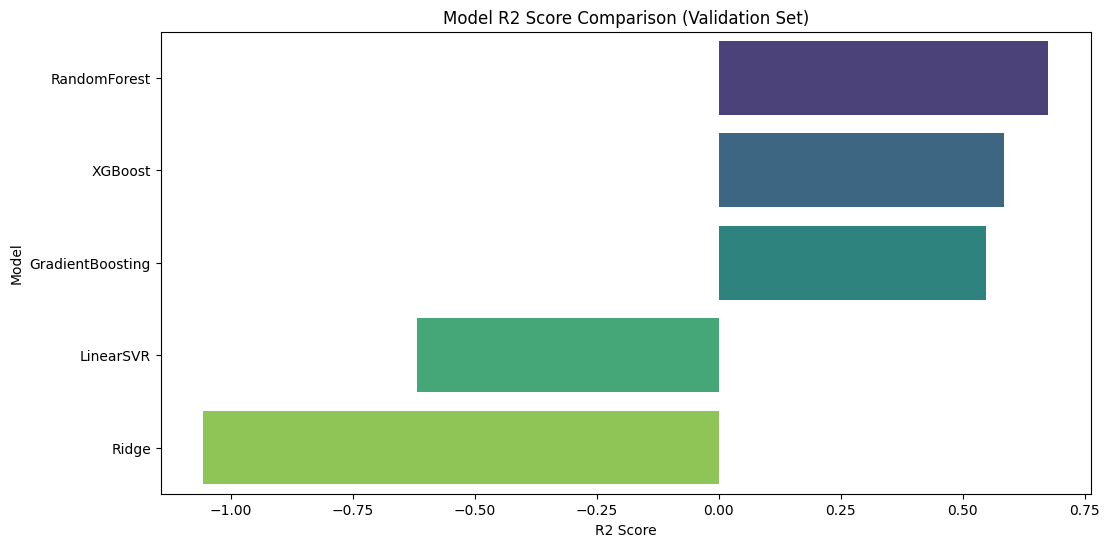

C:\Users\mercy\AppData\Local\Temp\ipykernel_25328\3734539189.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MAE', y='Model', data=res_df_val.sort_values('MAE', ascending=True), palette='plasma')


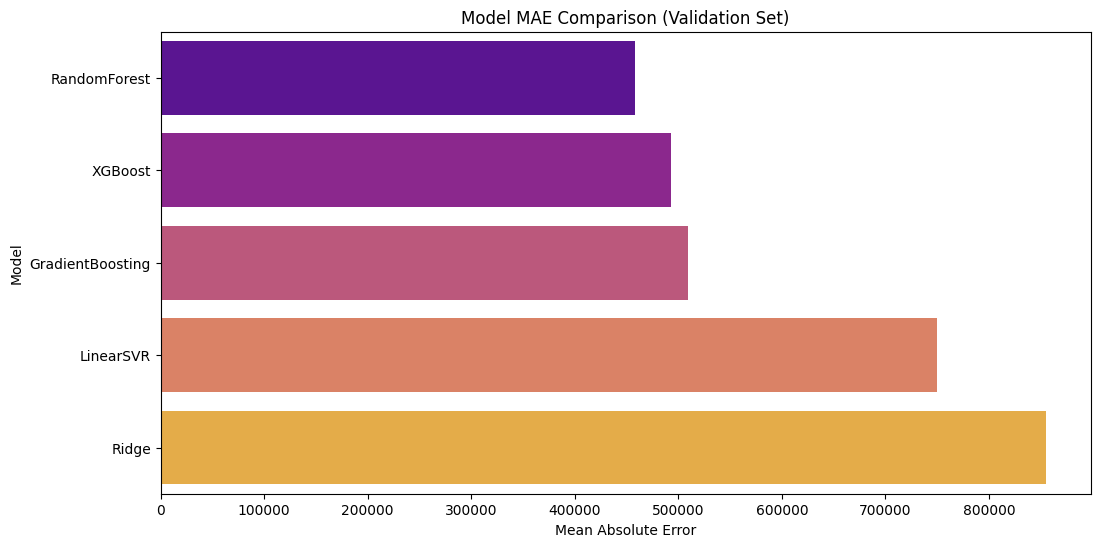

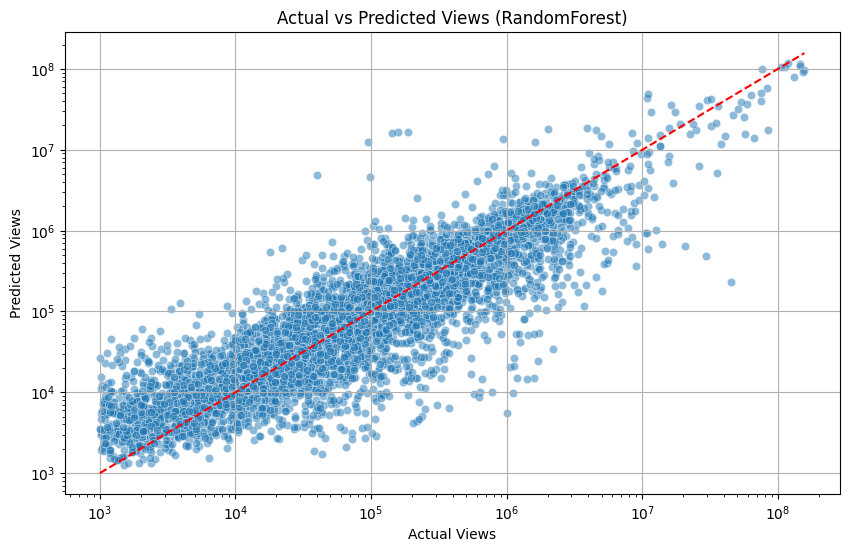

In [13]:
# %% === Visualization ===
plt.figure(figsize=(12, 6))
sns.barplot(x='R2', y='Model', data=res_df_val, palette='viridis')
plt.title('Model R2 Score Comparison (Validation Set)')
plt.xlabel('R2 Score')
plt.ylabel('Model')
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='MAE', y='Model', data=res_df_val.sort_values('MAE', ascending=True), palette='plasma')
plt.title('Model MAE Comparison (Validation Set)')
plt.xlabel('Mean Absolute Error')
plt.ylabel('Model')
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test_actual, y=preds_test, alpha=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Actual Views")
plt.ylabel("Predicted Views")
plt.title(f"Actual vs Predicted Views ({best_model_name})")
plt.grid(True)
plt.show()